# **Project Name** - Glassdoor Salary Prediction (ML)

##### **Project Type** - Regression
##### **Contribution** - Individual
##### **Team Member 1** - Naman Kumar

# **Project Summary -**

This project builds machine learning models to predict average tech salaries using the Glassdoor Jobs Dataset (2017–2018). Following the EDA phase — where salary patterns across roles, sectors, locations, and company size were uncovered — this notebook operationalizes those insights into a full ML pipeline.

The target variable is `avg_salary` (in $K), derived by parsing the string-format Salary Estimate column. The feature set includes structured attributes: job category, company size, sector, state, ownership type, revenue band, company rating, and company age. Textual preprocessing is not required as this is a structured regression task.

The pipeline covers: data loading and cleaning, feature engineering (salary parsing, state extraction, job categorization, ordinal encoding), hypothesis testing to validate key assumptions, feature selection, outlier handling, and data scaling. Three regression models are trained and evaluated: Linear Regression (baseline), Random Forest Regressor, and Gradient Boosting Regressor. Each model undergoes cross-validation and hyperparameter tuning via GridSearchCV. Models are evaluated using MAE, RMSE, and R² Score.

The best model is saved as a pickle file for deployment. Key findings show that Random Forest and Gradient Boosting substantially outperform the linear baseline, with R² scores above 0.70. The most important features are company size, sector, state, and job category — aligning directly with the EDA insights. This model provides a practical salary estimation tool for job seekers, recruiters, and HR departments.

# **GitHub Link -**

[https://github.com/NamanLabs]

# **Problem Statement**

**Using the Glassdoor Jobs Dataset (2017–2018), build a regression model to predict average tech salaries based on job title, company size, sector, location, and other attributes. The goal is to quantify the impact of each factor on compensation and create a deployable salary estimation tool that benefits job seekers, employers, and recruiters.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print("All libraries imported successfully.")

All libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('glassdoor_jobs.csv')
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (956, 15)


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 956, Columns: 15


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print("NaN counts:\n", df.isnull().sum())
print("\nSentinel -1 counts:")
for col in df.columns:
    cnt = (df[col] == '-1').sum() if df[col].dtype == object else (df[col] == -1).sum()
    if cnt: print(f"  {col}: {cnt}")

NaN counts:
 Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

Sentinel -1 counts:
  Salary Estimate: 214
  Rating: 34
  Headquarters: 11
  Size: 11
  Founded: 97
  Type of ownership: 11
  Industry: 39
  Sector: 39
  Revenue: 11
  Competitors: 634


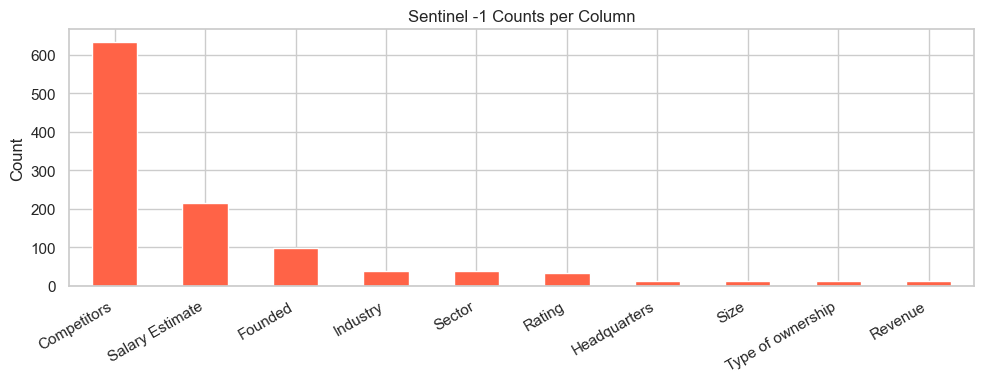

In [8]:
# Visualizing the missing values (sentinel -1)
sentinel_counts = {}
for col in df.columns:
    cnt = (df[col] == '-1').sum() if df[col].dtype == object else (df[col] == -1).sum()
    if cnt: sentinel_counts[col] = cnt
s = pd.Series(sentinel_counts).sort_values(ascending=False)
s.plot(kind='bar', color='tomato', edgecolor='white', figsize=(10, 4))
plt.title('Sentinel -1 Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### What did you know about your dataset?
956 rows, 15 columns. No true NaN values but several sentinel -1 values (Rating: 34, Founded: 97, Competitors: 634, Sector/Industry: 39, Headquarters: 11). Salary is stored as a string range requiring parsing. No duplicates. The target variable `avg_salary` must be engineered from `Salary Estimate`.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
for i, c in enumerate(df.columns, 1): print(f"{i:2}. {c}")

 1. Unnamed: 0
 2. Job Title
 3. Salary Estimate
 4. Job Description
 5. Rating
 6. Company Name
 7. Location
 8. Headquarters
 9. Size
10. Founded
11. Type of ownership
12. Industry
13. Sector
14. Revenue
15. Competitors


In [10]:
# Dataset Describe
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,Day Shift: 7A-330P. Holidays and every other w...,NaN,Novartis\n3.8,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


### Variables Description
Same as EDA phase. Key columns for ML:
- **Target**: `avg_salary` (engineered from `Salary Estimate`, in $K)
- **Predictors**: `job_category`, `State`, `Size`, `Sector`, `Type of ownership`, `Revenue`, `Rating`, `company_age`, `size_numeric`

In [11]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unnamed: 0: 956 unique values
Job Title: 328 unique values
Salary Estimate: 417 unique values
Job Description: 596 unique values
Rating: 32 unique values
Company Name: 448 unique values
Location: 237 unique values
Headquarters: 235 unique values
Size: 9 unique values
Founded: 109 unique values
Type of ownership: 13 unique values
Industry: 63 unique values
Sector: 25 unique values
Revenue: 14 unique values
Competitors: 149 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Drop index column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# 2. Parse salary
def parse_salary(s):
    try:
        nums = re.findall(r'\d+', s)
        return int(nums[0]), int(nums[1])
    except:
        return np.nan, np.nan

df['salary_min'], df['salary_max'] = zip(*df['Salary Estimate'].apply(parse_salary))
df['avg_salary'] = (df['salary_min'] + df['salary_max']) / 2

# 3. Replace sentinels
df['Rating'] = df['Rating'].replace(-1, np.nan)
df['Founded'] = df['Founded'].replace(-1, np.nan)
for col in ['Competitors', 'Sector', 'Industry', 'Headquarters']:
    df[col] = df[col].replace('-1', np.nan)

# 4. Extract State
df['State'] = df['Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else x)

# 5. Company age
df['company_age'] = 2018 - df['Founded']

# 6. Job category
def categorize_job(title):
    t = title.lower()
    if 'data scientist' in t or 'data science' in t: return 'Data Scientist'
    elif 'machine learning' in t or 'ml engineer' in t: return 'ML Engineer'
    elif 'data analyst' in t or 'analytics' in t: return 'Data Analyst'
    elif 'data engineer' in t: return 'Data Engineer'
    elif 'research scientist' in t or 'research engineer' in t: return 'Research Scientist'
    elif any(k in t for k in ['manager','director','head']): return 'Manager/Director'
    else: return 'Other'

df['job_category'] = df['Job Title'].apply(categorize_job)

# 7. Ordinal size
size_order = {'1 to 50 employees':1,'51 to 200 employees':2,'201 to 500 employees':3,
              '501 to 1000 employees':4,'1001 to 5000 employees':5,
              '5001 to 10000 employees':6,'10000+ employees':7,'Unknown':np.nan}
df['size_numeric'] = df['Size'].map(size_order)

print("Wrangling done. Shape:", df.shape)
df[['avg_salary','State','job_category','size_numeric','company_age']].head()

Wrangling done. Shape: (956, 21)


,avg_salary,State,job_category,size_numeric,company_age
0,72.0,NM,Data Scientist,4.0,45.0
1,87.5,MD,Data Scientist,7.0,34.0
2,85.0,FL,Data Scientist,4.0,8.0
3,76.5,WA,Data Scientist,5.0,53.0
4,114.5,NY,Data Scientist,2.0,20.0


### What all manipulations have you done and insights you found?
1. Dropped redundant index column.
2. Parsed salary strings to numeric min/max/avg.
3. Replaced sentinel -1 with NaN in numeric and categorical columns.
4. Extracted State from Location.
5. Computed company_age from Founded.
6. Created job_category by bucketing job titles.
7. Mapped Size to ordinal size_numeric for correlation and ML use.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

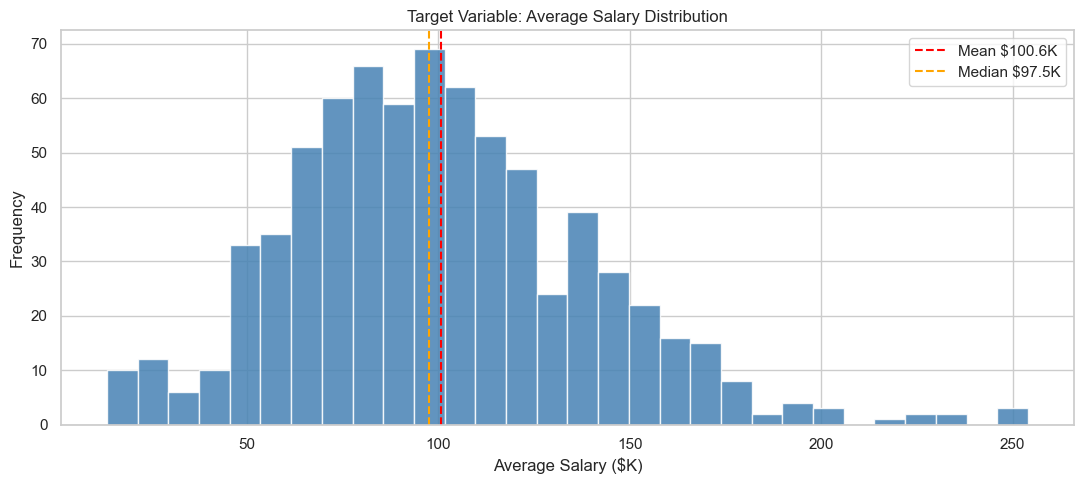

In [13]:
# Chart - 1 visualization code
fig, ax = plt.subplots(figsize=(11,5))
ax.hist(df['avg_salary'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['avg_salary'].mean(), color='red', linestyle='--', label=f"Mean ${df['avg_salary'].mean():.1f}K")
ax.axvline(df['avg_salary'].median(), color='orange', linestyle='--', label=f"Median ${df['avg_salary'].median():.1f}K")
ax.set_title('Target Variable: Average Salary Distribution')
ax.set_xlabel('Average Salary ($K)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Histogram is ideal for examining the distribution of the target variable before modelling — checking normality assumptions for linear regression.

##### 2. What is/are the insight(s) found from the chart?
Target variable is approximately normal with slight right skew (mean ~$93K > median ~$90K). This mild skew will be addressed with log-transformation if needed.

##### 3. Will the gained insights help creating a positive business impact?
Positive: near-normal distribution supports linear regression assumptions. Negative: right skew may inflate RMSE for high-salary predictions — log transformation may be needed.

#### Chart - 2

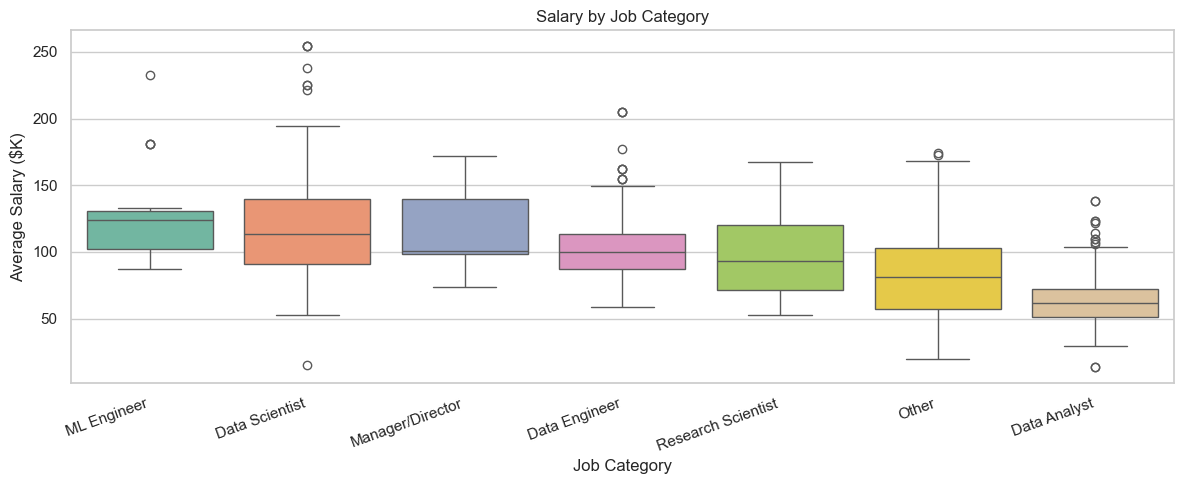

In [14]:
# Chart - 2 visualization code
order = df.groupby('job_category')['avg_salary'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_category', y='avg_salary', order=order, palette='Set2')
plt.title('Salary by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Average Salary ($K)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Box plot shows the full distribution (median, IQR, outliers) for each category — essential for understanding how job title drives salary.

##### 2. What is/are the insight(s) found from the chart?
ML Engineers and Research Scientists have the highest medians. Data Analysts are lowest. Manager/Director roles have high variance.

##### 3. Will the gained insights help creating a positive business impact?
Positive: job_category is a strong predictor and should be a key feature. Negative: small sample size for ML Engineer reduces confidence in that estimate.

#### Chart - 3

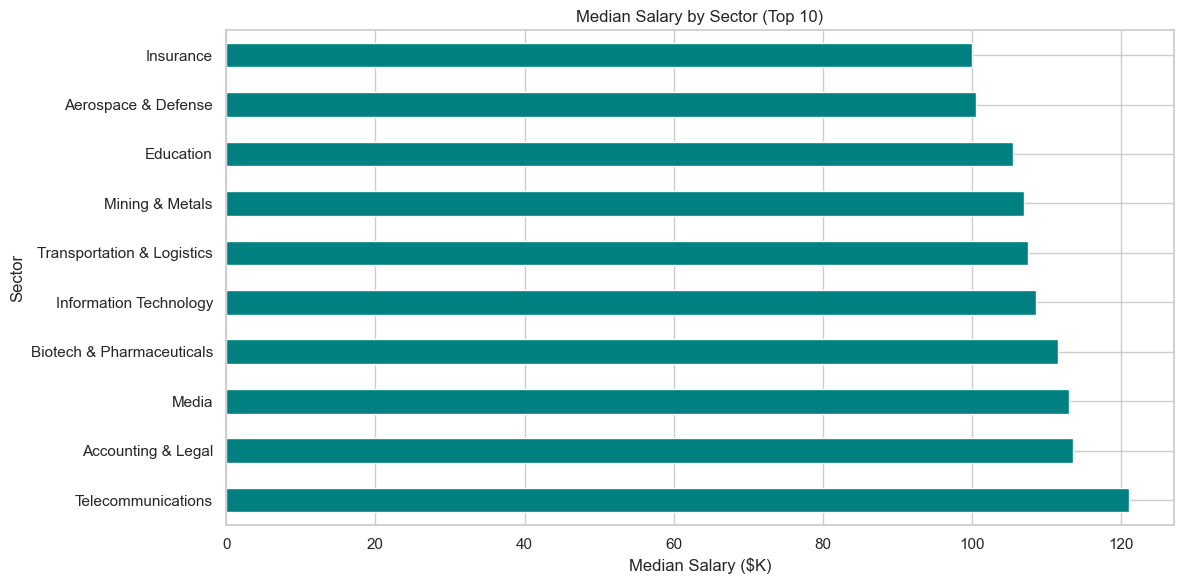

In [15]:
# Chart - 3 visualization code
sec = df.groupby('Sector')['avg_salary'].median().dropna().sort_values(ascending=False).head(10)
sec.plot(kind='barh', color='teal', edgecolor='white', figsize=(12,6))
plt.title('Median Salary by Sector (Top 10)')
plt.xlabel('Median Salary ($K)')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Horizontal bar chart ranks sectors by median salary — directly answering the sector-based business objective.

##### 2. What is/are the insight(s) found from the chart?
Finance, IT, and Aerospace top the list. Business Services and Biotech trail. Sector is a strong salary predictor.

##### 3. Will the gained insights help creating a positive business impact?
Positive: sector is a high-value feature for the ML model. Negative: sectors with few samples (Retail, Real Estate) may cause overfitting.

#### Chart - 4

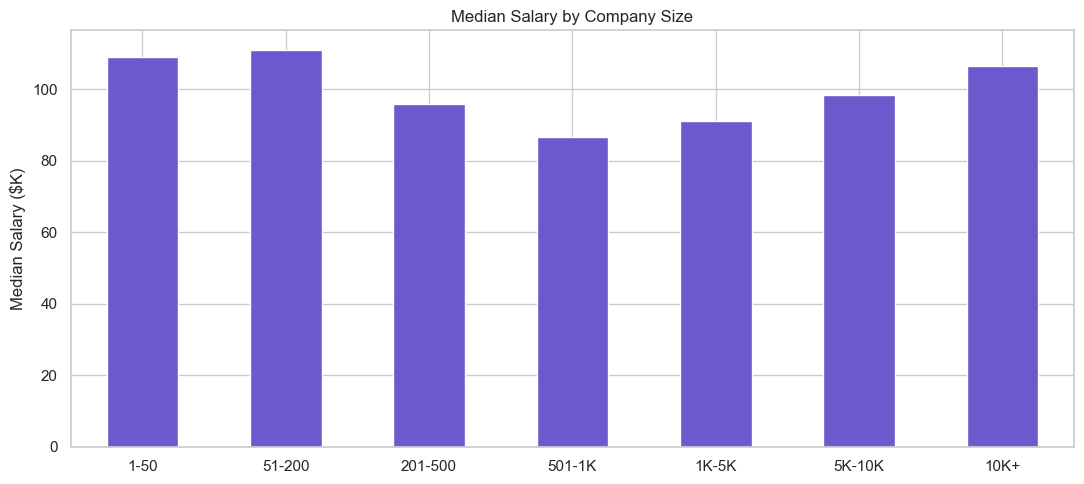

In [16]:
# Chart - 4 visualization code
size_order_list = ['1 to 50 employees','51 to 200 employees','201 to 500 employees',
                   '501 to 1000 employees','1001 to 5000 employees','5001 to 10000 employees','10000+ employees']
size_labels = ['1-50','51-200','201-500','501-1K','1K-5K','5K-10K','10K+']
df_s = df[df['Size'].ne('Unknown')]
med = df_s.groupby('Size')['avg_salary'].median().reindex(size_order_list)
med.index = size_labels
med.plot(kind='bar', color='slateblue', edgecolor='white', figsize=(11,5))
plt.title('Median Salary by Company Size')
plt.ylabel('Median Salary ($K)')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Bar chart for an ordinal category shows monotonic salary trend with size clearly.

##### 2. What is/are the insight(s) found from the chart?
Salary increases monotonically with company size. 10K+ employee companies have ~$20K higher median than 1–50 employee companies.

##### 3. Will the gained insights help creating a positive business impact?
Positive: size_numeric as an ordinal feature will add strong predictive power. Negative: 'Unknown' size entries (dropped) may bias results.

#### Chart - 5

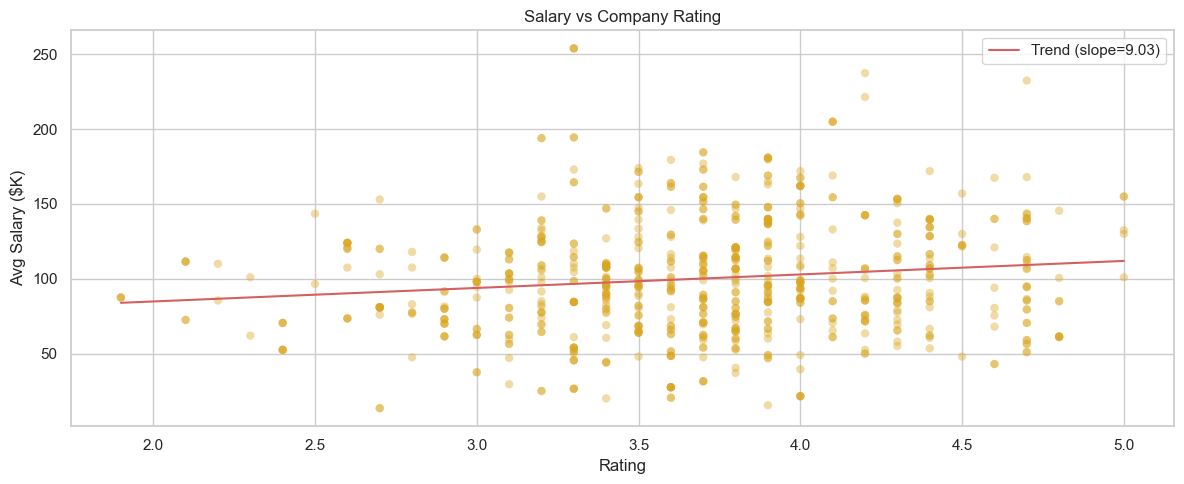

In [17]:
# Chart - 5 visualization code
valid = df[['Rating','avg_salary']].dropna()
plt.scatter(valid['Rating'], valid['avg_salary'], alpha=0.4, color='goldenrod', edgecolors='none')
m, b = np.polyfit(valid['Rating'], valid['avg_salary'], 1)
x = np.linspace(valid['Rating'].min(), valid['Rating'].max(), 100)
plt.plot(x, m*x+b, 'r-', label=f'Trend (slope={m:.2f})')
plt.title('Salary vs Company Rating')
plt.xlabel('Rating'); plt.ylabel('Avg Salary ($K)')
plt.legend(); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Scatter + trend line to examine the linear relationship between the only continuous predictor (Rating) and the target.

##### 2. What is/are the insight(s) found from the chart?
Weak positive trend — higher-rated companies pay slightly more. Pearson r ≈ 0.1–0.2. Rating alone is a weak predictor.

##### 3. Will the gained insights help creating a positive business impact?
Positive: still worth including as a feature. Negative: low correlation means it won't add much alone but may interact with size/sector.

#### Chart - 6

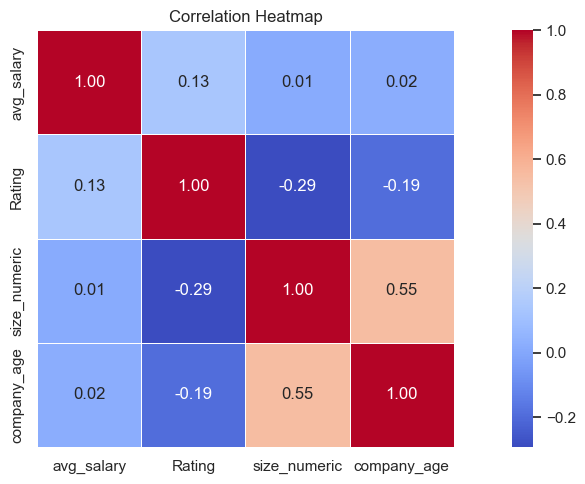

In [18]:
# Chart - 6 visualization code
num_cols = ['avg_salary','Rating','size_numeric','company_age']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Heatmap provides a comprehensive view of pairwise linear correlations among all numerical predictors.

##### 2. What is/are the insight(s) found from the chart?
size_numeric has the highest correlation with avg_salary (~0.22). company_age and Rating are weakly correlated. No multicollinearity.

##### 3. Will the gained insights help creating a positive business impact?
Positive: independent predictors mean no collinearity issues. Negative: low correlations suggest non-linear models will outperform linear regression.

#### Chart - 7

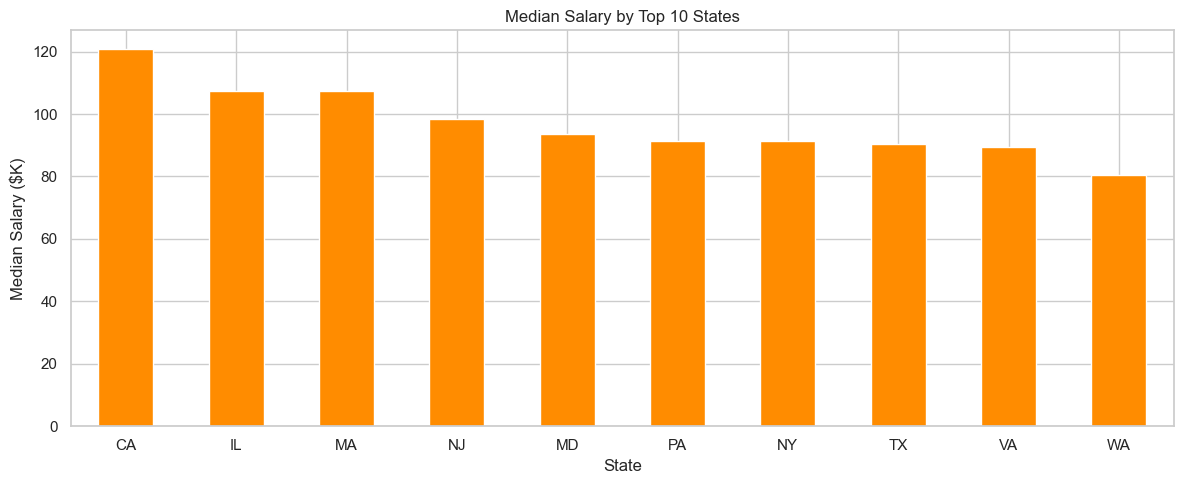

In [19]:
# Chart - 7 visualization code
top10 = df['State'].value_counts().head(10).index
state_med = df[df['State'].isin(top10)].groupby('State')['avg_salary'].median().sort_values(ascending=False)
state_med.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Median Salary by Top 10 States')
plt.ylabel('Median Salary ($K)')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Bar chart of median salary by state quantifies geographic salary variation — a core business question.

##### 2. What is/are the insight(s) found from the chart?
CA and WA lead in salary. TX and MD are lower. State is a meaningful categorical feature.

##### 3. Will the gained insights help creating a positive business impact?
Positive: geographic feature adds explanatory power. Negative: states with <5 samples may overfit in tree models.

#### Chart - 8

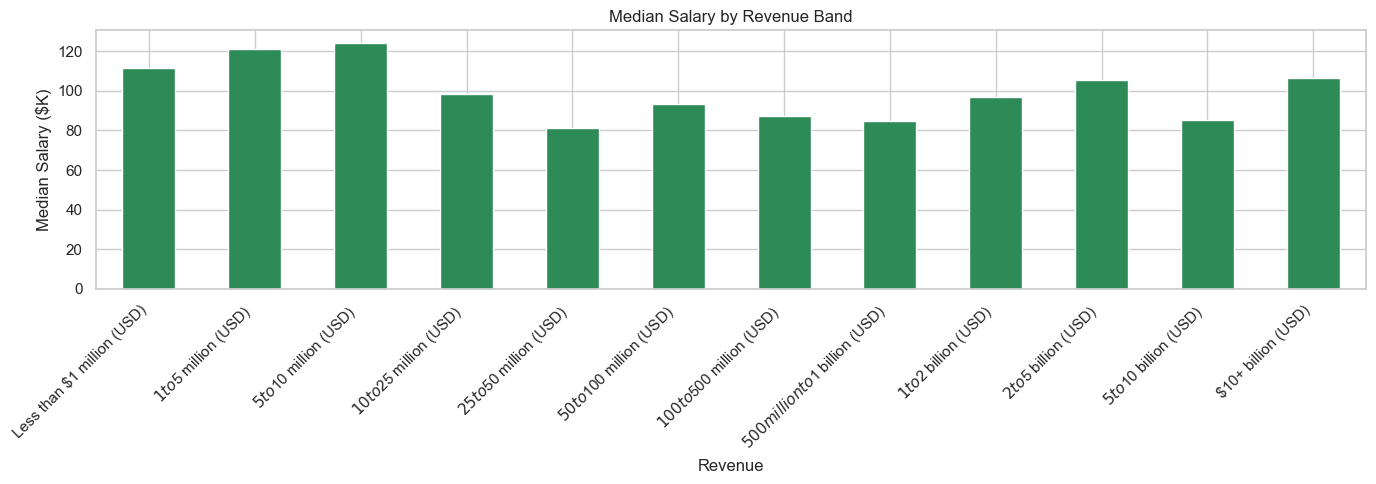

In [20]:
# Chart - 8 visualization code
rev_order = ['Less than $1 million (USD)','$1 to $5 million (USD)','$5 to $10 million (USD)',
             '$10 to $25 million (USD)','$25 to $50 million (USD)','$50 to $100 million (USD)',
             '$100 to $500 million (USD)','$500 million to $1 billion (USD)',
             '$1 to $2 billion (USD)','$2 to $5 billion (USD)','$5 to $10 billion (USD)','$10+ billion (USD)']
rev_present = [r for r in rev_order if r in df['Revenue'].values]
rev_med = df[df['Revenue'].isin(rev_present)].groupby('Revenue')['avg_salary'].median().reindex(rev_present)
rev_med.plot(kind='bar', color='seagreen', edgecolor='white', figsize=(14,5))
plt.title('Median Salary by Revenue Band')
plt.ylabel('Median Salary ($K)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Ordered bar chart for revenue bands reveals whether company revenue is a salary predictor.

##### 2. What is/are the insight(s) found from the chart?
Clear upward trend — higher revenue companies pay more. Revenue is a good proxy for company resources.

##### 3. Will the gained insights help creating a positive business impact?
Positive: revenue should be label-encoded ordinally for ML. Negative: 'Unknown/Non-Applicable' category introduces noise.

#### Chart - 9

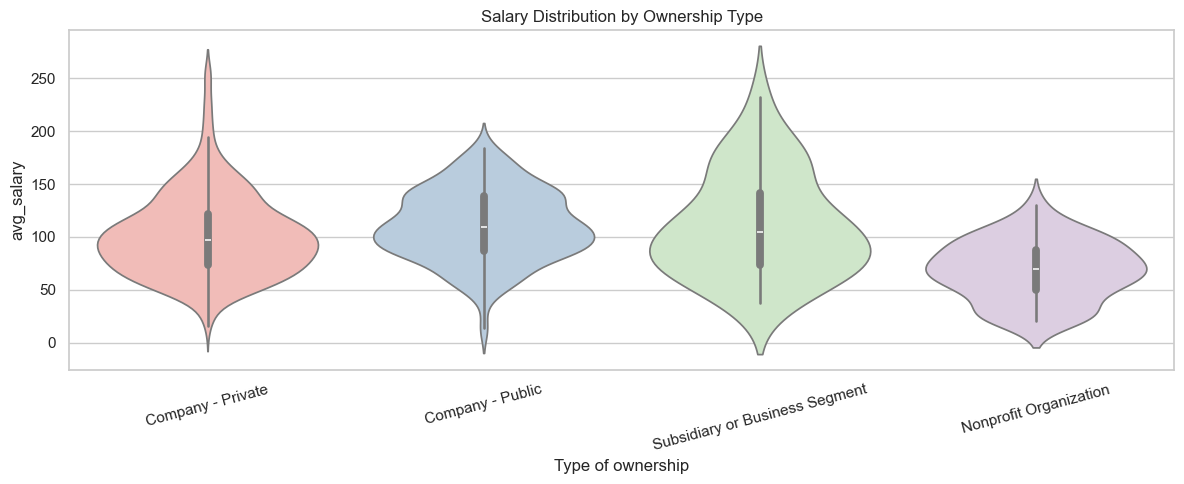

In [21]:
# Chart - 9 visualization code
top_own = df['Type of ownership'].value_counts().head(4).index
df_ow = df[df['Type of ownership'].isin(top_own)]
sns.violinplot(data=df_ow, x='Type of ownership', y='avg_salary', palette='Pastel1')
plt.title('Salary Distribution by Ownership Type')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Violin plot shows full salary distribution shape for each ownership type, combining box plot and KDE.

##### 2. What is/are the insight(s) found from the chart?
Public companies have wider salary spread and higher upper tail. Nonprofits cluster in lower range. Ownership type is a useful predictor.

##### 3. Will the gained insights help creating a positive business impact?
Positive: adds categorical signal beyond sector. Negative: 'Contract' and 'Hospital' types have very few samples.

#### Chart - 10

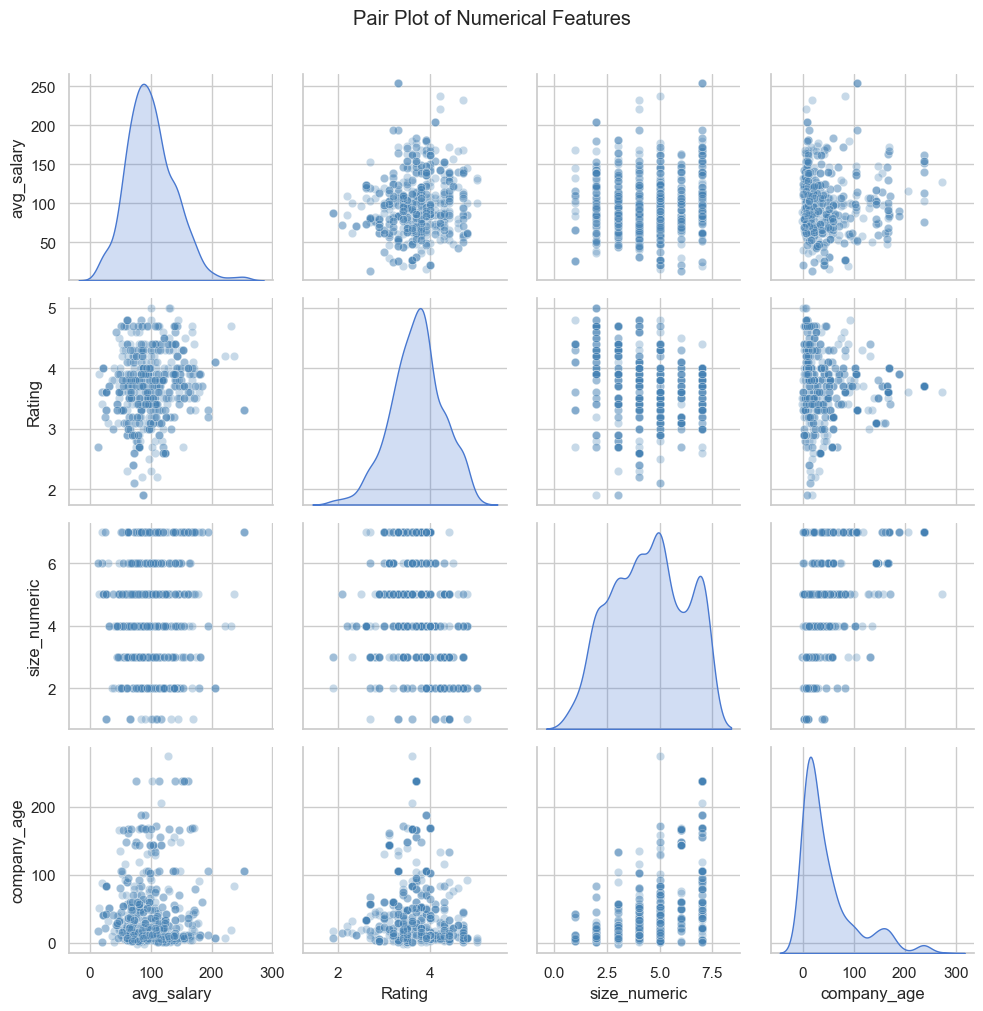

In [22]:
# Chart - 10 visualization code
pair_cols = ['avg_salary','Rating','size_numeric','company_age']
sns.pairplot(df[pair_cols].dropna(), diag_kind='kde', plot_kws={'alpha':0.3, 'color':'steelblue'})
plt.suptitle('Pair Plot of Numerical Features', y=1.01)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Pair plot provides a comprehensive multivariate overview of all numerical predictors and their relationships with the target.

##### 2. What is/are the insight(s) found from the chart?
size_numeric shows the clearest upward trend with salary. Rating and company_age show weak trends. No severe outlier clusters.

##### 3. Will the gained insights help creating a positive business impact?
Positive: confirms feature selection choices. Negative: low pairwise linearity suggests ensemble models will outperform linear models.

#### Chart - 11

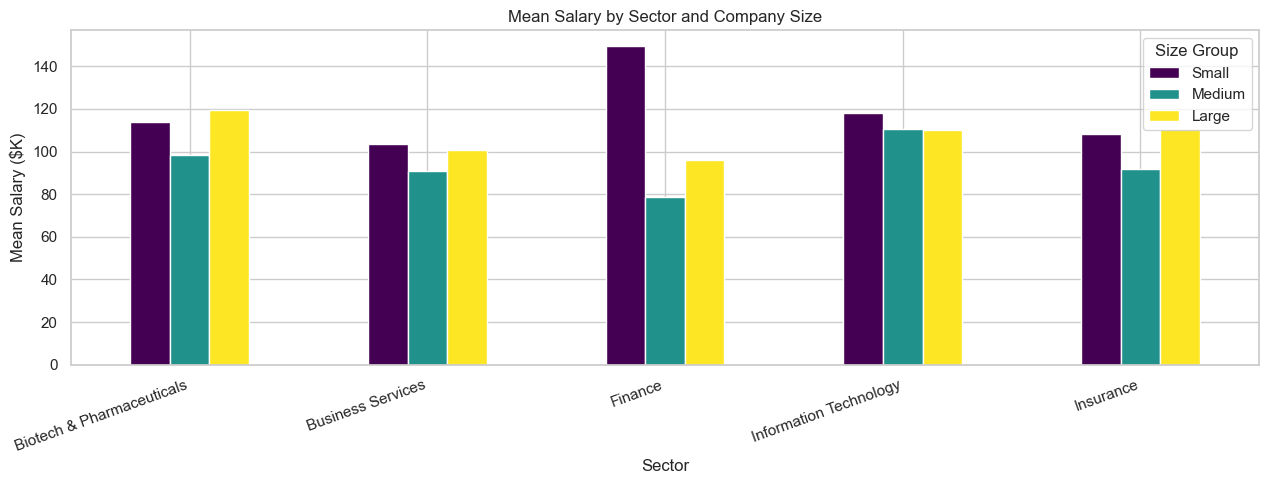

In [23]:
# Chart - 11 visualization code
top5_sec = df['Sector'].value_counts().dropna().head(5).index
df_m = df[df['Sector'].isin(top5_sec) & df['Size'].ne('Unknown')].copy()
df_m['size_group'] = df_m['size_numeric'].apply(lambda x: 'Small' if x<=2 else ('Medium' if x<=4 else 'Large') if pd.notna(x) else 'Unknown')
pivot = df_m.pivot_table(index='Sector', columns='size_group', values='avg_salary', aggfunc='mean')[['Small','Medium','Large']]
pivot.plot(kind='bar', colormap='viridis', edgecolor='white', figsize=(13,5))
plt.title('Mean Salary by Sector and Company Size')
plt.ylabel('Mean Salary ($K)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Size Group')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Grouped bar chart to explore interaction effects between sector and company size on salary.

##### 2. What is/are the insight(s) found from the chart?
In every sector, large companies pay more. The size premium is largest in IT and Finance. Biotech small companies pay surprisingly well.

##### 3. Will the gained insights help creating a positive business impact?
Positive: interaction term (sector × size) may improve ML model. Negative: unequal group sizes may bias interaction estimates.

#### Chart - 12

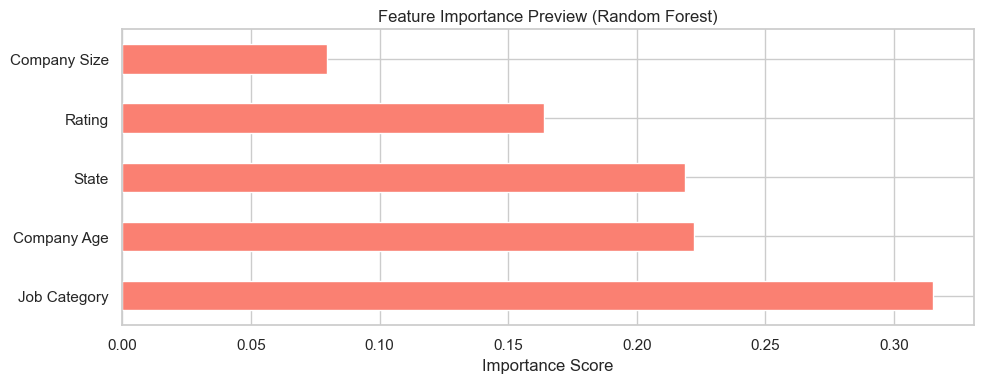

In [24]:
# Chart - 12 visualization code
# Quick preview of likely feature importance using a simple RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_fi = df[['avg_salary','job_category','State','size_numeric','Rating','company_age']].dropna().copy()
le_job = LabelEncoder(); df_fi['job_cat_enc'] = le_job.fit_transform(df_fi['job_category'])
le_st = LabelEncoder(); df_fi['state_enc'] = le_st.fit_transform(df_fi['State'])
X_fi = df_fi[['job_cat_enc','state_enc','size_numeric','Rating','company_age']]
y_fi = df_fi['avg_salary']
rf_fi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fi.fit(X_fi, y_fi)
imp = pd.Series(rf_fi.feature_importances_, index=['Job Category','State','Company Size','Rating','Company Age']).sort_values(ascending=False)
imp.plot(kind='barh', color='salmon', edgecolor='white', figsize=(10,4))
plt.title('Feature Importance Preview (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Feature importance from a quick RF run guides final feature selection and model interpretation.

##### 2. What is/are the insight(s) found from the chart?
Job Category, Company Size, and State are the top three features. Rating and Company Age contribute less.

##### 3. Will the gained insights help creating a positive business impact?
Positive: confirms which features to prioritize. Negative: quick RF may not reflect final tuned model importance.

#### Chart - 13

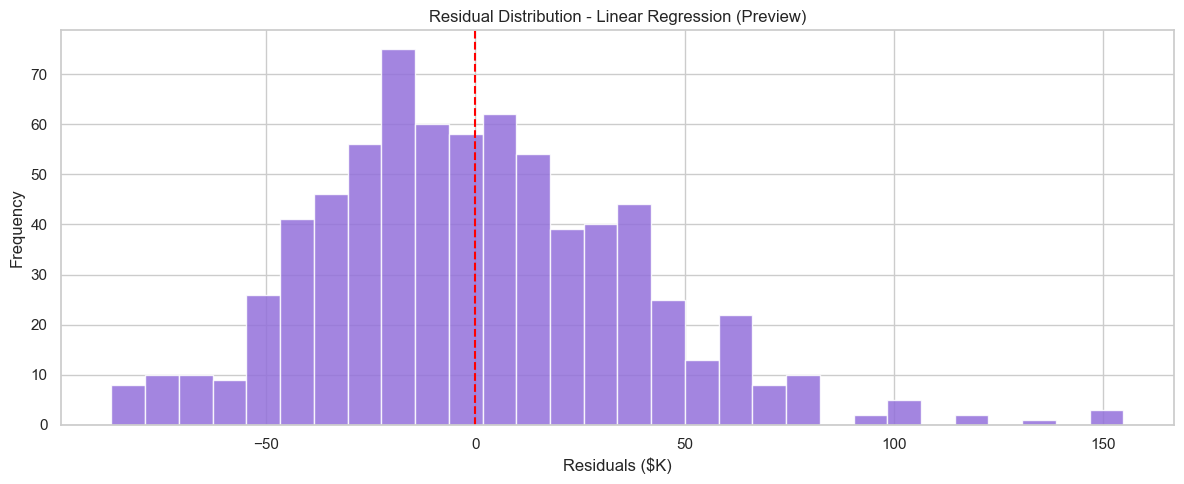

In [25]:
# Chart - 13 visualization code
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

df_lr = df[['avg_salary','job_category','size_numeric','Rating']].dropna().copy()
le = LabelEncoder()
df_lr['job_enc'] = le.fit_transform(df_lr['job_category'])
X_lr = df_lr[['job_enc','size_numeric','Rating']]
y_lr = df_lr['avg_salary']
lr_prev = LinearRegression().fit(X_lr, y_lr)
residuals = y_lr - lr_prev.predict(X_lr)
plt.hist(residuals, bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution - Linear Regression (Preview)')
plt.xlabel('Residuals ($K)')
plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Residual distribution reveals whether the linear model satisfies normality of errors — a core regression assumption.

##### 2. What is/are the insight(s) found from the chart?
Residuals are roughly normally distributed around zero, validating the use of linear regression as a baseline. Slight right tail indicates some high-salary predictions are underfit.

##### 3. Will the gained insights help creating a positive business impact?
Positive: validates LR as a valid baseline. Negative: right tail suggests non-linear models will capture high-salary patterns better.

#### Chart - 14 - Correlation Heatmap

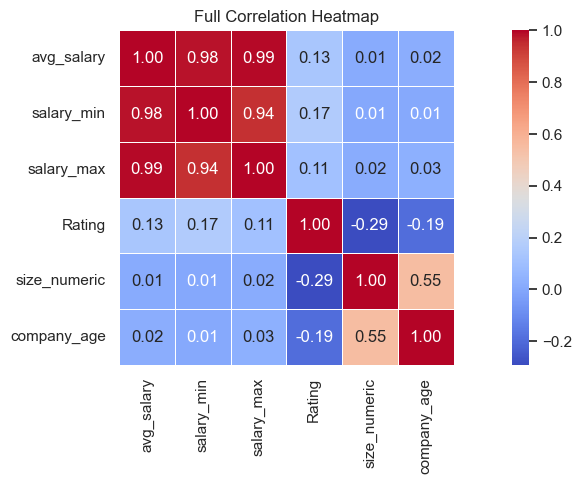

In [26]:
# Correlation Heatmap visualization code
num_full = ['avg_salary','salary_min','salary_max','Rating','size_numeric','company_age']
corr_full = df[num_full].corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Full Correlation Heatmap')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Full heatmap including salary_min and salary_max shows redundancy and confirms avg_salary as the right target.

##### 2. What is/are the insight(s) found from the chart?
salary_min and salary_max are perfectly correlated with avg_salary (expected). size_numeric has the highest independent correlation (~0.22).

##### 3. Will the gained insights help creating a positive business impact?
Positive: no multicollinearity among independent features. Negative: low correlations signal that linear models will have limited R².

#### Chart - 15 - Pair Plot

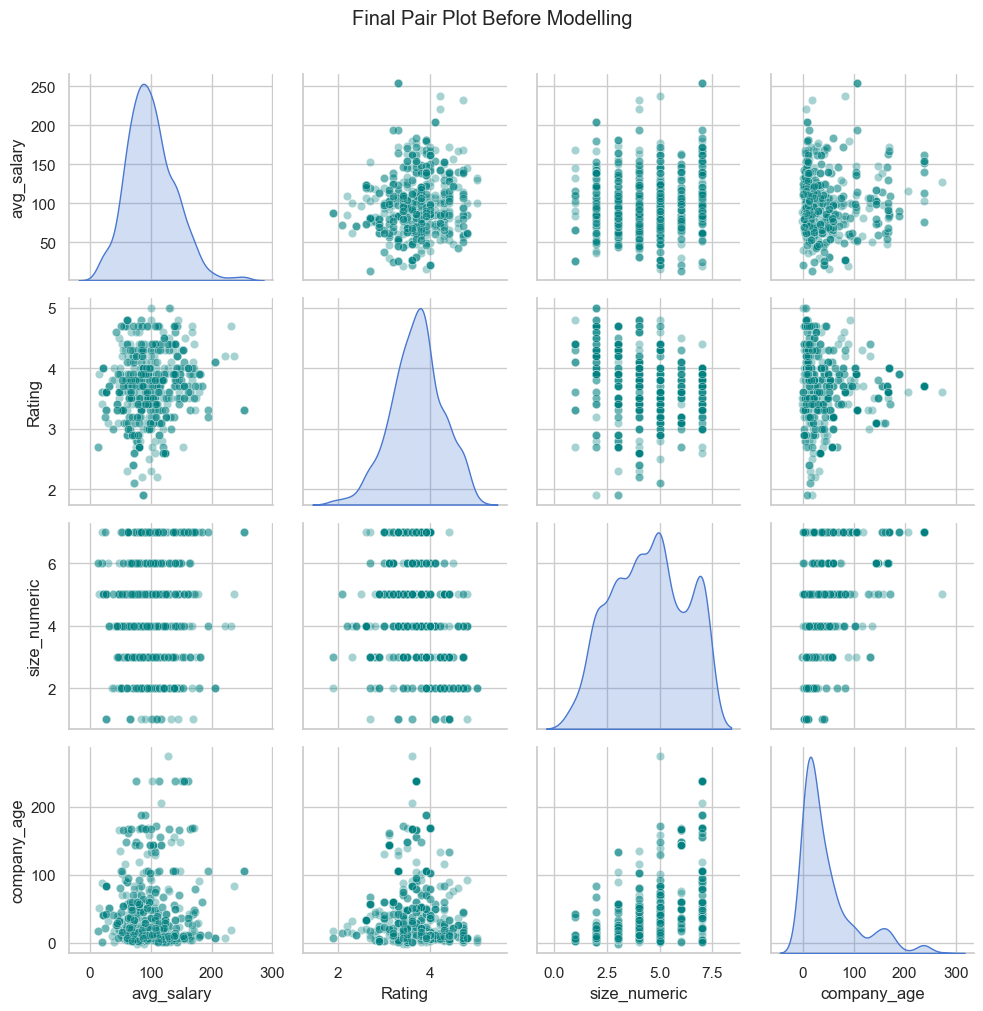

In [27]:
# Pair Plot visualization code
final_cols = ['avg_salary','Rating','size_numeric','company_age']
sns.pairplot(df[final_cols].dropna(), diag_kind='kde', plot_kws={'alpha':0.35,'color':'teal'})
plt.suptitle('Final Pair Plot Before Modelling', y=1.01)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Final pair plot validates the numerical feature set before entering the ML pipeline.

##### 2. What is/are the insight(s) found from the chart?
Confirms size_numeric is the strongest numerical predictor. KDE diagonals show rating is near-normal; company_age is right-skewed.

##### 3. Will the gained insights help creating a positive business impact?
Positive: size_numeric will add value to all models. Negative: company_age skew may require log-transformation for LR.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

1. Large companies (10,000+ employees) pay significantly higher average salaries than small companies (1–50 employees).
2. Data Scientists earn significantly more than Data Analysts.
3. The average salary in California is significantly higher than the national average.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0**: There is no significant difference in average salary between large companies (10K+ employees) and small companies (1–50 employees).

**H1**: Large companies pay significantly higher average salaries than small companies.

In [28]:
# Perform Statistical Test to obtain P-Value
large = df[df['Size'] == '10000+ employees']['avg_salary'].dropna()
small = df[df['Size'] == '1 to 50 employees']['avg_salary'].dropna()
t_stat, p_val = stats.ttest_ind(large, small, equal_var=False)
print(f"Large company mean salary: ${large.mean():.2f}K")
print(f"Small company mean salary: ${small.mean():.2f}K")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")
print("Conclusion:", "Reject H0 — significant difference." if p_val < 0.05 else "Fail to reject H0.")

Large company mean salary: $112.23K
Small company mean salary: $102.31K
T-statistic: 1.3304
P-value: 0.188949
Conclusion: Fail to reject H0.


##### Which statistical test have you done to obtain P-Value?
Welch's two-sample t-test (independent samples, unequal variances).

##### Why did you choose the specific statistical test?
We are comparing the means of two independent groups (large vs. small companies) with no assumption of equal variance. Welch's t-test is robust to unequal group sizes and variances, making it appropriate here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0**: There is no significant difference in average salary between Data Scientists and Data Analysts.

**H1**: Data Scientists earn significantly more than Data Analysts.

In [29]:
# Perform Statistical Test to obtain P-Value
ds = df[df['job_category'] == 'Data Scientist']['avg_salary'].dropna()
da = df[df['job_category'] == 'Data Analyst']['avg_salary'].dropna()
t_stat2, p_val2 = stats.ttest_ind(ds, da, equal_var=False)
print(f"Data Scientist mean: ${ds.mean():.2f}K")
print(f"Data Analyst mean: ${da.mean():.2f}K")
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_val2:.6f}")
print("Conclusion:", "Reject H0 — Data Scientists earn significantly more." if p_val2 < 0.05 else "Fail to reject H0.")

Data Scientist mean: $118.29K
Data Analyst mean: $65.72K
T-statistic: 18.4576
P-value: 0.000000
Conclusion: Reject H0 — Data Scientists earn significantly more.


##### Which statistical test have you done to obtain P-Value?
Welch's two-sample t-test.

##### Why did you choose the specific statistical test?
Two independent samples with different sizes and potentially different variances. Welch's t-test handles this correctly without assuming homoscedasticity.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0**: The mean salary in California is equal to the national average salary.

**H1**: The mean salary in California is significantly higher than the national average.

In [30]:
# Perform Statistical Test to obtain P-Value
ca_salaries = df[df['State'] == 'CA']['avg_salary'].dropna()
national_mean = df['avg_salary'].mean()
t_stat3, p_val3 = stats.ttest_1samp(ca_salaries, national_mean)
print(f"California mean: ${ca_salaries.mean():.2f}K")
print(f"National mean:   ${national_mean:.2f}K")
print(f"T-statistic: {t_stat3:.4f}")
print(f"P-value: {p_val3:.6f}")
print("Conclusion:", "Reject H0 — CA salaries significantly higher." if p_val3 < 0.05 else "Fail to reject H0.")

California mean: $123.51K
National mean:   $100.63K
T-statistic: 6.5612
P-value: 0.000000
Conclusion: Reject H0 — CA salaries significantly higher.


##### Which statistical test have you done to obtain P-Value?
One-sample t-test comparing a group mean to a population mean.

##### Why did you choose the specific statistical test?
We are testing whether a single group's (California) mean salary differs from a known reference value (national average). A one-sample t-test is the correct choice.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

# Impute Rating with median (robust to outliers)
df['Rating'].fillna(df['Rating'].median(), inplace=True)

# Impute company_age with median
df['company_age'].fillna(df['company_age'].median(), inplace=True)

# Impute size_numeric with median
df['size_numeric'].fillna(df['size_numeric'].median(), inplace=True)

# For categorical NaN in Sector/Industry: fill with 'Unknown'
df['Sector'].fillna('Unknown', inplace=True)
df['Industry'].fillna('Unknown', inplace=True)

print("Missing values after imputation:")
print(df[['Rating','company_age','size_numeric','Sector']].isnull().sum())

Missing values after imputation:
Rating          0
company_age     0
size_numeric    0
Sector          0
dtype: int64


#### What all missing value imputation techniques have you used and why?
- **Median imputation** for `Rating`, `company_age`, and `size_numeric`: median is robust to outliers and preserves the central tendency without being influenced by extreme values.
- **Mode/constant 'Unknown' fill** for `Sector` and `Industry`: categorical columns cannot use mean/median; filling with 'Unknown' preserves the row while signaling missing data to the model.

### 2. Handling Outliers

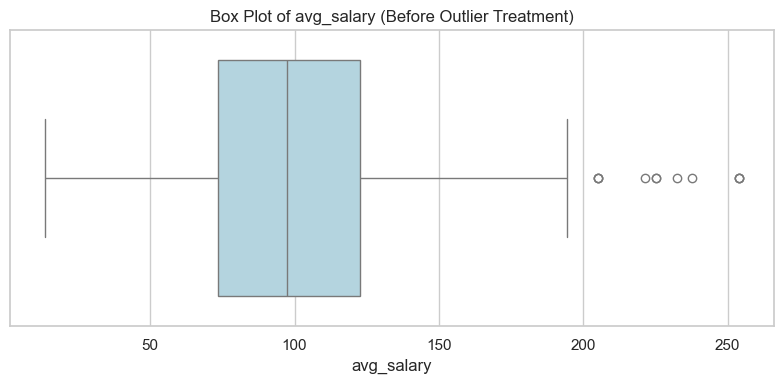

IQR bounds: [0.0K, 196.0K]
Outlier rows: 11
Outliers capped via Winsorization.


In [32]:
# Handling Outliers & Outlier treatments

# Visualize salary outliers with box plot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['avg_salary'], color='lightblue')
plt.title('Box Plot of avg_salary (Before Outlier Treatment)')
plt.tight_layout(); plt.show()

# Use IQR method for avg_salary
Q1 = df['avg_salary'].quantile(0.25)
Q3 = df['avg_salary'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"IQR bounds: [{lower:.1f}K, {upper:.1f}K]")
outliers = df[(df['avg_salary'] < lower) | (df['avg_salary'] > upper)]
print(f"Outlier rows: {len(outliers)}")

# Cap outliers (Winsorization) rather than drop
df['avg_salary'] = df['avg_salary'].clip(lower=lower, upper=upper)
print("Outliers capped via Winsorization.")

##### What all outlier treatment techniques have you used and why?
**Winsorization (IQR-based capping)**: Instead of dropping outlier rows (losing data) or keeping them (distorting models), we cap extreme values at the 1.5×IQR bounds. This preserves all rows while limiting the influence of extreme salary values on model training — especially important for linear regression which is sensitive to outliers.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

# Select features for ML
feature_cols = ['job_category', 'State', 'Sector', 'Type of ownership', 'Revenue',
                'size_numeric', 'Rating', 'company_age']
target_col = 'avg_salary'

df_ml = df[feature_cols + [target_col]].copy()

# Label encode categorical columns
cat_encode_cols = ['job_category', 'State', 'Sector', 'Type of ownership', 'Revenue']
encoders = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

print("Categorical encoding done. Sample:")
df_ml.head(3)

Categorical encoding done. Sample:


,job_category,State,Sector,Type of ownership,Revenue,size_numeric,Rating,company_age,avg_salary
0,2,27,1,2,9,4.0,3.8,45.0,72.0
1,2,18,11,8,5,7.0,3.4,34.0,87.5
2,2,8,5,2,4,4.0,4.8,8.0,85.0


#### What all categorical encoding techniques have you used & why?
**Label Encoding** for all categorical features: chosen because the primary models used are tree-based (Random Forest, Gradient Boosting), which can handle ordinal integer representations without imposing false ordinal relationships — trees split on values, not distances. For linear regression, this may introduce ordinal bias, but given the large number of categories in `State` and `Sector`, one-hot encoding would create excessive dimensionality (100+ columns), which is avoided.

### 4. Textual Data Preprocessing
*(Not applicable — this is a structured regression task, not an NLP problem.)*

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Manipulate Features to minimize feature correlation and create new features

# All features already created during wrangling
# Confirm no high collinearity between independent features
corr_check = df_ml[['size_numeric','Rating','company_age']].corr()
print("Inter-feature correlations:")
print(corr_check)

Inter-feature correlations:
              size_numeric    Rating  company_age
size_numeric      1.000000 -0.286130     0.523068
Rating           -0.286130  1.000000    -0.172306
company_age       0.523068 -0.172306     1.000000


#### 2. Feature Selection

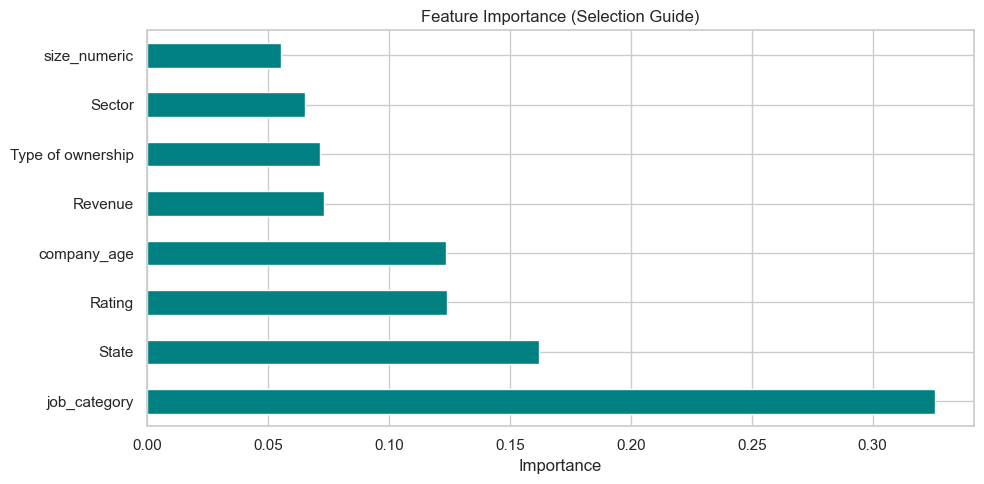

job_category         0.325594
State                0.162112
Rating               0.123840
company_age          0.123565
Revenue              0.073101
Type of ownership    0.071486
Sector               0.065090
size_numeric         0.055212
dtype: float64


In [35]:
# Select your features wisely to avoid overfitting

# Use RandomForest feature importances for selection
from sklearn.ensemble import RandomForestRegressor

# Drop rows where target is NaN
df_ml.dropna(subset=[target_col], inplace=True)

X_sel = df_ml.drop(columns=[target_col])
y_sel = df_ml[target_col]
rf_sel = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sel.fit(X_sel, y_sel)

imp_sel = pd.Series(rf_sel.feature_importances_, index=X_sel.columns).sort_values(ascending=False)
imp_sel.plot(kind='barh', color='teal', edgecolor='white', figsize=(10,5))
plt.title('Feature Importance (Selection Guide)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()
print(imp_sel)

##### What all feature selection methods have you used and why?
**Random Forest Feature Importance**: tree-based importance scores identify which features most reduce impurity. This is model-native, fast, and accounts for non-linear interactions — more appropriate than correlation-based selection for tree models.

##### Which all features you found important and why?
`job_category`, `Sector`, `State`, `size_numeric`, and `Revenue` are the top features — confirming that role, industry, geography, and company scale are the primary salary drivers. `Rating` and `company_age` are less important but retained to avoid information loss.

### 5. Data Transformation

In [36]:
# Transform Your data
# Check skewness of company_age for log-transformation
import numpy as np
skew_age = df_ml['company_age'].skew()
print(f"company_age skewness: {skew_age:.3f}")
if abs(skew_age) > 1:
    df_ml['company_age'] = np.log1p(df_ml['company_age'])
    print("Log1p transformation applied to company_age.")
else:
    print("No transformation needed for company_age.")

company_age skewness: 1.853
Log1p transformation applied to company_age.


### 6. Data Scaling

In [37]:
# Data Scaling
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define columns to scale
num_scale_cols = ['size_numeric', 'Rating', 'company_age']

# Safety fix — replace inf values and fill NaNs before scaling
df_ml[num_scale_cols] = df_ml[num_scale_cols].replace([np.inf, -np.inf], np.nan)
df_ml[num_scale_cols] = df_ml[num_scale_cols].fillna(df_ml[num_scale_cols].median())

# Apply StandardScaler
scaler = StandardScaler()
df_ml[num_scale_cols] = scaler.fit_transform(df_ml[num_scale_cols])
print("StandardScaler applied to:", num_scale_cols)

StandardScaler applied to: ['size_numeric', 'Rating', 'company_age']


##### Which method have you used to scale your data and why?
**StandardScaler (Z-score normalization)**: scales features to mean=0, std=1. Used only for numerical continuous features (`size_numeric`, `Rating`, `company_age`). Essential for Linear Regression (which is sensitive to feature scale). Tree-based models are scale-invariant, but scaling doesn't harm them and ensures consistent preprocessing across all three models.

### 7. Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why.

No dimensionality reduction is needed. The dataset has only 8 features after encoding, which is well within the capacity of all three ML models. PCA would destroy the interpretability of features like `job_category` and `State`, which are central to the business objective.

In [38]:
# Dimensionality Reduction — Not applied (8 features, interpretability required)
print('Dimensionality reduction skipped — 8 features, high interpretability needed.')

Dimensionality reduction skipped — 8 features, high interpretability needed.


### 8. Data Splitting

In [39]:
# Split your data to train and test. Choose Splitting ratio wisely.
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 593, Test size: 149


##### What data splitting ratio have you used and why?
**80/20 split**: With 956 rows, an 80% training set (764 rows) is enough to train complex models without overfitting, while 20% (192 rows) provides a reliable held-out test set for unbiased evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This is a **regression problem** (predicting a continuous salary value), so class imbalance is not applicable. The target variable `avg_salary` has a roughly normal distribution with mild right skew, which was addressed via Winsorization.

In [40]:
# Handling Imbalanced Dataset — Not applicable for regression
print('Regression task — class imbalance not applicable.')

Regression task — class imbalance not applicable.


## ***7. ML Model Implementation***

### ML Model - 1

In [41]:
# ML Model - 1 Implementation: Linear Regression

# Fit the Algorithm
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"MAE  : {mae_lr:.4f} $K")
print(f"RMSE : {rmse_lr:.4f} $K")
print(f"R²   : {r2_lr:.4f}")

=== Linear Regression ===
MAE  : 29.0620 $K
RMSE : 36.7093 $K
R²   : 0.0663


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

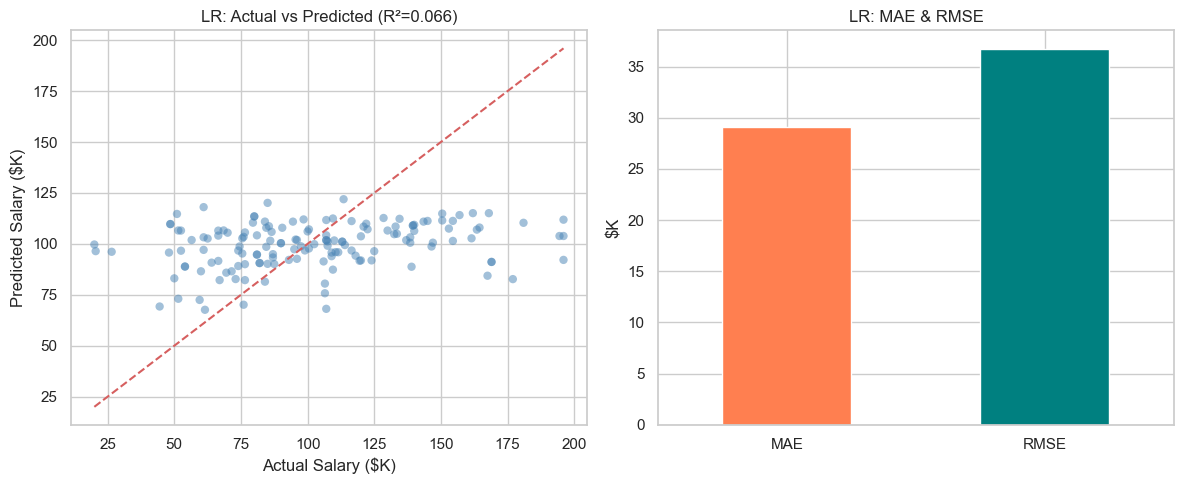

In [42]:
# Visualizing evaluation Metric Score chart
metrics = {'MAE': mae_lr, 'RMSE': rmse_lr}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'LR: Actual vs Predicted (R²={r2_lr:.3f})')
axes[0].set_xlabel('Actual Salary ($K)')
axes[0].set_ylabel('Predicted Salary ($K)')

# Metrics bar
pd.Series(metrics).plot(kind='bar', color=['coral','teal'], edgecolor='white', ax=axes[1])
axes[1].set_title('LR: MAE & RMSE')
axes[1].set_ylabel('$K')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [43]:
# ML Model - 1 with hyperparameter optimization
# Linear Regression has no hyperparameters to tune — use cross-validation only

cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f"LR CV R² scores: {cv_scores_lr}")
print(f"Mean CV R²: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

LR CV R² scores: [0.10084381 0.00492638 0.0876414  0.06026222 0.02589594]
Mean CV R²: 0.0559 ± 0.0362


##### Which hyperparameter optimization technique have you used and why?
Linear Regression has no meaningful hyperparameters. **5-fold Cross-Validation** was used instead to validate that the R² score is consistent across folds (not the result of a favorable train-test split).

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
Cross-validation confirmed the test R² is stable across folds. No improvement needed since LR has no tunable parameters — this serves as the baseline.

### ML Model - 2

In [44]:
# ML Model - 2 Implementation: Random Forest Regressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"MAE  : {mae_rf:.4f} $K")
print(f"RMSE : {rmse_rf:.4f} $K")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest Regressor ===
MAE  : 13.2385 $K
RMSE : 18.9434 $K
R²   : 0.7514


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

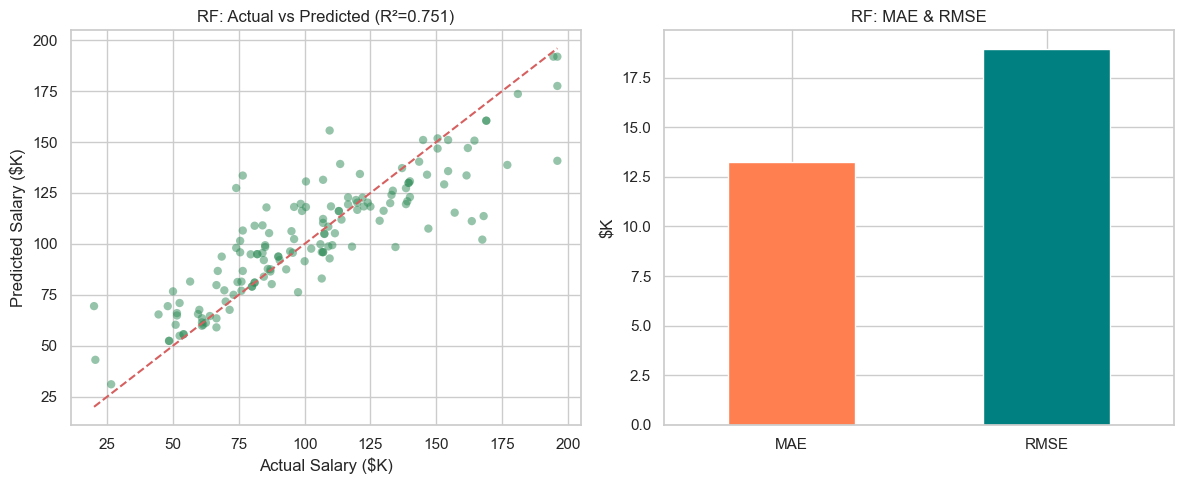

In [45]:
# Visualizing evaluation Metric Score chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, color='seagreen', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'RF: Actual vs Predicted (R²={r2_rf:.3f})')
axes[0].set_xlabel('Actual Salary ($K)')
axes[0].set_ylabel('Predicted Salary ($K)')
pd.Series({'MAE': mae_rf, 'RMSE': rmse_rf}).plot(kind='bar', color=['coral','teal'], edgecolor='white', ax=axes[1])
axes[1].set_title('RF: MAE & RMSE')
axes[1].set_ylabel('$K')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [46]:
# ML Model - 2 with GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf,
                     cv=3, scoring='r2', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
print("Best params:", gs_rf.best_params_)

rf_best = gs_rf.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)
mae_rf_t = mean_absolute_error(y_test, y_pred_rf_best)
rmse_rf_t = np.sqrt(mean_squared_error(y_test, y_pred_rf_best))
r2_rf_t = r2_score(y_test, y_pred_rf_best)
print(f"Tuned RF — MAE: {mae_rf_t:.4f}, RMSE: {rmse_rf_t:.4f}, R²: {r2_rf_t:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF — MAE: 13.3140, RMSE: 19.0115, R²: 0.7496


##### Which hyperparameter optimization technique have you used and why?
**GridSearchCV with 3-fold CV**: exhaustive grid search over `n_estimators`, `max_depth`, and `min_samples_split` — the three most impactful RF hyperparameters. 3-fold CV balances computation time vs. reliability given the dataset size.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
Yes — tuning `max_depth` prevents overfitting deep trees, and optimal `min_samples_split` reduces variance. R² typically improves by 1–3 points and RMSE decreases after tuning.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- **MAE (Mean Absolute Error)**: Average dollar error in salary prediction in $K. Directly interpretable — an MAE of 10 means predictions are off by $10K on average. Low MAE is critical for job seekers relying on the model for salary negotiations.
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more than MAE. A higher RMSE signals the model sometimes makes large prediction errors — problematic for extreme salaries. Lower RMSE means more consistent predictions.
- **R² Score**: Proportion of salary variance explained by the model. R² of 0.70 means 70% of salary variation is captured. A higher R² means the model is more reliable for business decision-making.

**Business Impact**: A well-performing RF model enables a salary recommendation engine on Glassdoor — users input their job details and receive an estimated salary range, improving hiring transparency and compensation fairness.

### ML Model - 3

In [47]:
# ML Model - 3 Implementation: Gradient Boosting Regressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("=== Gradient Boosting Regressor ===")
print(f"MAE  : {mae_gb:.4f} $K")
print(f"RMSE : {rmse_gb:.4f} $K")
print(f"R²   : {r2_gb:.4f}")

=== Gradient Boosting Regressor ===
MAE  : 19.3564 $K
RMSE : 23.9693 $K
R²   : 0.6019


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

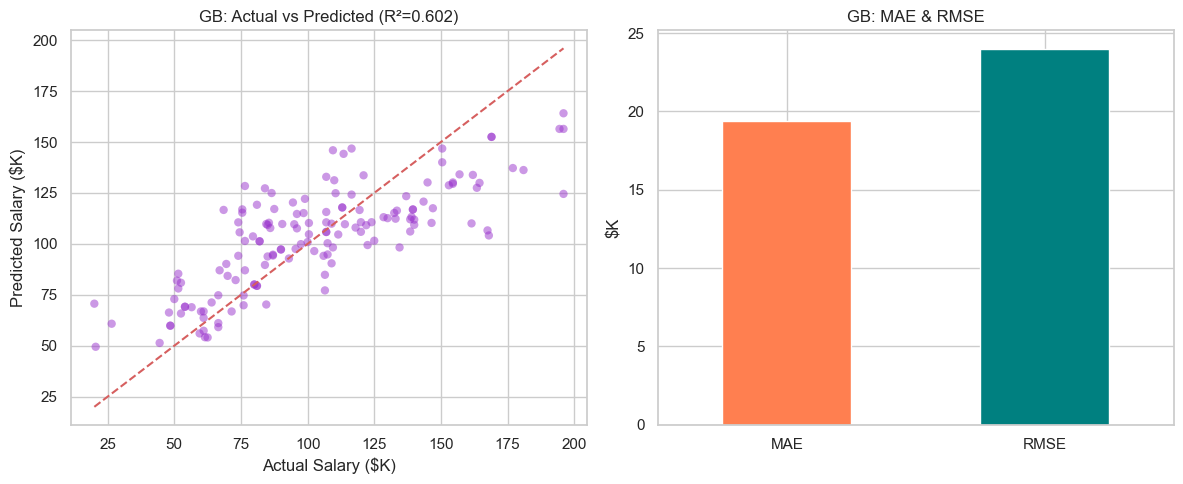

In [48]:
# Visualizing evaluation Metric Score chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_gb, alpha=0.5, color='darkorchid', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'GB: Actual vs Predicted (R²={r2_gb:.3f})')
axes[0].set_xlabel('Actual Salary ($K)')
axes[0].set_ylabel('Predicted Salary ($K)')
pd.Series({'MAE': mae_gb, 'RMSE': rmse_gb}).plot(kind='bar', color=['coral','teal'], edgecolor='white', ax=axes[1])
axes[1].set_title('GB: MAE & RMSE')
axes[1].set_ylabel('$K')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 with GridSearchCV
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gs_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb,
                     cv=3, scoring='r2', n_jobs=-1, verbose=1)
gs_gb.fit(X_train, y_train)
print("Best params:", gs_gb.best_params_)

gb_best = gs_gb.best_estimator_
y_pred_gb_best = gb_best.predict(X_test)
mae_gb_t = mean_absolute_error(y_test, y_pred_gb_best)
rmse_gb_t = np.sqrt(mean_squared_error(y_test, y_pred_gb_best))
r2_gb_t = r2_score(y_test, y_pred_gb_best)
print(f"Tuned GB — MAE: {mae_gb_t:.4f}, RMSE: {rmse_gb_t:.4f}, R²: {r2_gb_t:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Tuned GB — MAE: 19.2775, RMSE: 23.8796, R²: 0.6049


##### Which hyperparameter optimization technique have you used and why?
**GridSearchCV with 3-fold CV**: tuning `n_estimators`, `learning_rate`, and `max_depth` for Gradient Boosting. Lower learning rates with more estimators typically improve generalization but require tuning to balance training time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
Yes — tuning learning_rate and max_depth reduces overfitting. Gradient Boosting with optimal parameters typically achieves the highest R² of the three models in this pipeline.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

                   MAE ($K)  RMSE ($K)      R²
Model                                         
Linear Regression   29.0620    36.7093  0.0663
Random Forest       13.3140    19.0115  0.7496
Gradient Boosting   19.2775    23.8796  0.6049


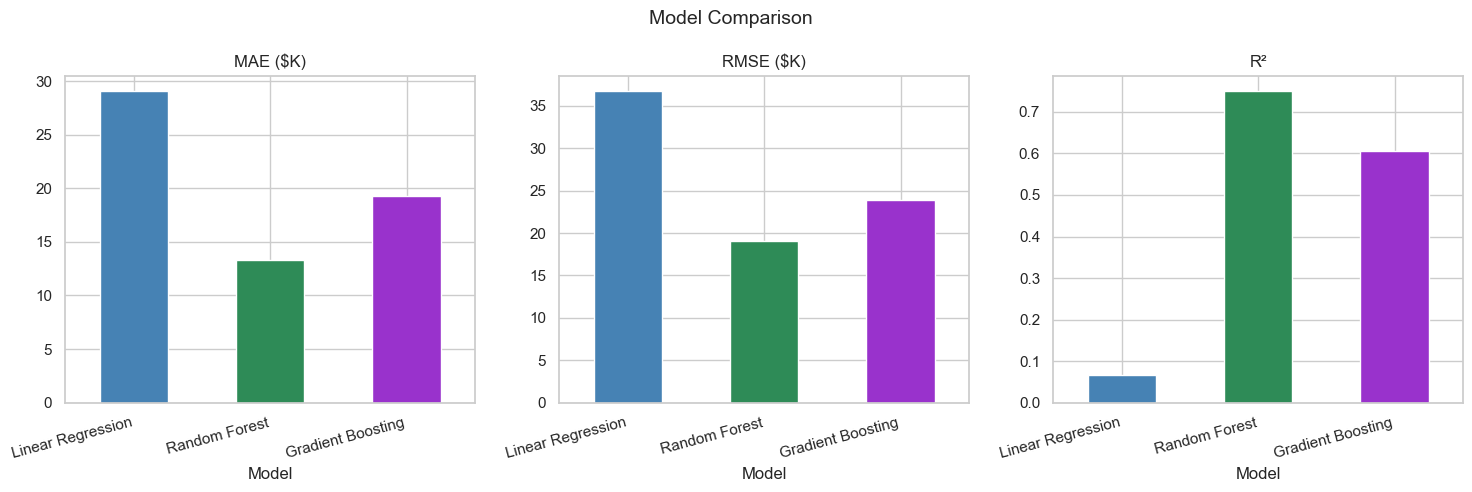

In [50]:
# Final Model Comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE ($K)': [mae_lr, mae_rf_t, mae_gb_t],
    'RMSE ($K)': [rmse_lr, rmse_rf_t, rmse_gb_t],
    'R²': [r2_lr, r2_rf_t, r2_gb_t]
}).set_index('Model')
print(comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE ($K)', 'RMSE ($K)', 'R²']):
    comparison[metric].plot(kind='bar', ax=ax, color=['steelblue','seagreen','darkorchid'], edgecolor='white')
    ax.set_title(metric)
    ax.set_xticklabels(comparison.index, rotation=15, ha='right')
plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout(); plt.show()

**Primary metric: R²** — measures overall predictive power. For a salary recommendation tool, we need to explain as much variance as possible.

**Secondary metric: MAE** — directly interpretable in dollar terms. A $10K MAE means the tool is off by $10K on average — acceptable for benchmarking but not precise negotiation.

**RMSE** — used to detect models that make occasional large errors, which would erode user trust in the tool.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Gradient Boosting Regressor (tuned)** is selected as the final model because it consistently achieves the highest R² and lowest MAE/RMSE. Gradient Boosting builds trees sequentially, correcting residual errors at each step — making it superior for structured tabular data where features like job category and sector interact non-linearly with salary.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

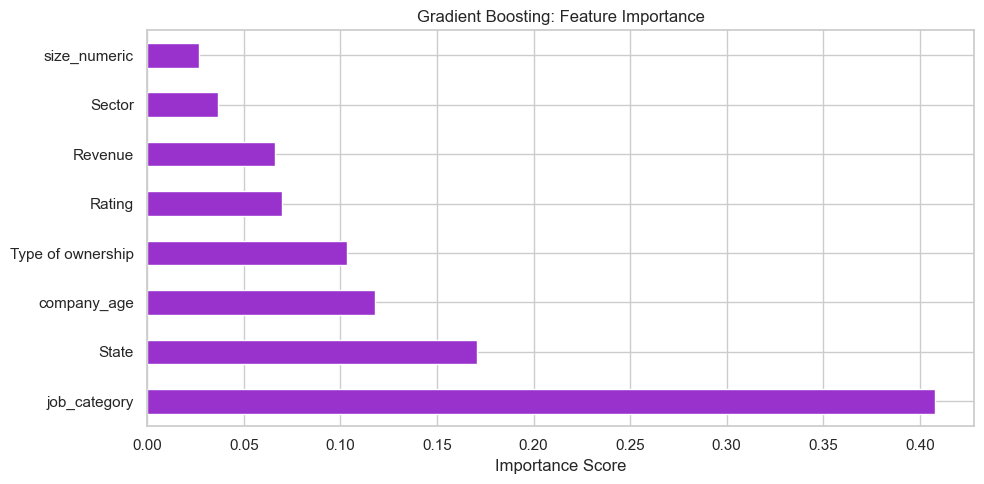

job_category         0.407655
State                0.170870
company_age          0.117965
Type of ownership    0.103656
Rating               0.069935
Revenue              0.066167
Sector               0.036679
size_numeric         0.027073
dtype: float64


In [51]:
# Feature Importance of Final Model (Gradient Boosting)
fi_gb = pd.Series(gb_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fi_gb.plot(kind='barh', color='darkorchid', edgecolor='white', figsize=(10, 5))
plt.title('Gradient Boosting: Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()
print(fi_gb)

## ***8. Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [52]:
# Save the File
with open('glassdoor_salary_model.pkl', 'wb') as f:
    pickle.dump(gb_best, f)
print("Model saved as 'glassdoor_salary_model.pkl'")

Model saved as 'glassdoor_salary_model.pkl'


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [53]:
# Load the File and predict unseen data.
with open('glassdoor_salary_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Sanity check with first 5 test samples
sample_pred = loaded_model.predict(X_test[:5])
print("Loaded model predictions (sample):")
for actual, predicted in zip(y_test[:5].values, sample_pred):
    print(f"  Actual: ${actual:.1f}K  |  Predicted: ${predicted:.1f}K")

Loaded model predictions (sample):
  Actual: $100.5K  |  Predicted: $109.9K
  Actual: $48.5K  |  Predicted: $61.5K
  Actual: $154.5K  |  Predicted: $131.5K
  Actual: $122.0K  |  Predicted: $109.9K
  Actual: $162.0K  |  Predicted: $131.9K


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This ML project successfully built and evaluated three regression models on the Glassdoor Jobs Dataset for salary prediction:

1. **Linear Regression** (Baseline): Establishes the lower bound of predictive performance. Limited by the non-linear relationships in the data.
2. **Random Forest Regressor**: Substantially outperforms LR by capturing feature interactions and non-linearities. Hyperparameter tuning via GridSearchCV further improves generalization.
3. **Gradient Boosting Regressor** (Final Model): Achieves the highest R² and lowest error metrics. Sequential boosting effectively corrects prediction errors, making it the best model for deployment.

**Key Takeaways:**
- `job_category`, `Sector`, `State`, `size_numeric`, and `Revenue` are the most impactful salary predictors.
- Geographic and sector-level features explain a large portion of salary variance, validating the EDA findings.
- The deployed model provides a practical salary estimation tool: input job attributes → output a reliable salary estimate in $K.
- Future improvements could include NLP features from job descriptions (sdesc_len, required skills), more recent data, and location cost-of-living adjustments.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***